## ECE226 Final Project: Hardware-Software Co-design & Custom Accelerators
## Group 19 Team Members: Sean Lipps, Pranav Mekkoth, Jaehyung Lim

In [1]:
!source /tools/Xilinx/Vitis_HLS/2024.1/settings64.sh
!source /opt/xilinx/xrt/setup.sh

Autocomplete enabled for the xbutil command
Autocomplete enabled for the xbmgmt command
XILINX_XRT        : /opt/xilinx/xrt
PATH              : /opt/xilinx/xrt/bin:/home/j.lim.473/miniconda3/envs/hls4ml-tutorial/bin:/home/j.lim.473/.vscode-server/cli/servers/Stable-ce099c1ed25d9eb3076c11e4a280f3eb52b4fbeb/server/bin/remote-cli:/tools/Xilinx/Vitis_HLS/2024.1/bin:/tools/Xilinx/Model_Composer/2024.1/bin:/tools/Xilinx/Vitis/2024.1/bin:/tools/Xilinx/Vitis/2024.1/gnu/microblaze/lin/bin:/tools/Xilinx/Vitis/2024.1/gnu/microblaze/linux_toolchain/lin64_le/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch32/lin/gcc-arm-linux-gnueabi/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch32/lin/gcc-arm-none-eabi/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch64/lin/aarch64-linux/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch64/lin/aarch64-none/bin:/tools/Xilinx/Vitis/2024.1/gnu/armr5/lin/gcc-arm-none-eabi/bin:/tools/Xilinx/Vitis/2024.1/aietools/bin:/tools/Xilinx/Vitis/2024.1/gnu/riscv/lin/riscv64-unknown-elf/bin:/tools/Xilinx/Vivado/

## Importing MNIST dataset

In [2]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Standard reproducibility settings
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# Load the data (replaces train_test_split and fetch_openml)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Basic Preprocessing
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize
y_train = to_categorical(y_train, 10)            # One-hot encode for 10 digits
y_test = to_categorical(y_test, 10)

2026-03-11 08:50:20.795204: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 08:50:20.914029: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Building Model using a single Conv2D block

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Activation, BatchNormalization, GlobalMaxPooling2D, MaxPooling2D, Input

model = Sequential([
    Input(shape=(28, 28, 1)),
    
    # Conv Layer
    Conv2D(16, (3, 3), padding='same', name='conv2'),
    BatchNormalization(),
    Activation('relu'),
    
    # NEW: Shrink spatial dimensions from 28x28 to 14x14
    # This reduces the "Global" operation work by 4x
    MaxPooling2D(pool_size=(2, 2)), 
    
    # Collapse to 32 units
    GlobalMaxPooling2D(),
    
    # Output
    Dense(10, activation='softmax')
])

## Training the model
We use Adam optimizer with categorical crossentropy loss.

In [81]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Define the schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.006,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

# Pass the schedule to the optimizer
adam = Adam(learning_rate=lr_schedule)

model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(
    x_train,
    y_train,
    batch_size=1024,
    epochs=30,
    validation_split=0.25,
    shuffle=True
)

Epoch 1/30
44/44 [==============================] - 1s 23ms/step - loss: 1.0056 - accuracy: 0.6608 - val_loss: 1.1572 - val_accuracy: 0.6099
Epoch 2/30
44/44 [==============================] - 1s 21ms/step - loss: 0.9837 - accuracy: 0.6694 - val_loss: 1.2239 - val_accuracy: 0.6046
Epoch 3/30
44/44 [==============================] - 1s 21ms/step - loss: 0.9811 - accuracy: 0.6729 - val_loss: 1.1728 - val_accuracy: 0.6094
Epoch 4/30
44/44 [==============================] - 1s 21ms/step - loss: 0.9784 - accuracy: 0.6740 - val_loss: 1.1281 - val_accuracy: 0.6210
Epoch 5/30
44/44 [==============================] - 1s 21ms/step - loss: 0.9798 - accuracy: 0.6706 - val_loss: 1.2036 - val_accuracy: 0.5996
Epoch 6/30
44/44 [==============================] - 1s 21ms/step - loss: 0.9774 - accuracy: 0.6724 - val_loss: 1.1207 - val_accuracy: 0.6247
Epoch 7/30
44/44 [==============================] - 1s 21ms/step - loss: 0.9798 - accuracy: 0.6714 - val_loss: 1.2632 - val_accuracy: 0.5745
Epoch 8/30
44

## Checking the model's performance

In [82]:
from sklearn.metrics import accuracy_score, roc_curve, auc
import time
import tracemalloc

# Warm-up run to initialize the model on the hardware
_ = model.predict(x_test, verbose=0)

# Measure Inference Performance (Latency and Memory)
tracemalloc.start()
start_time = time.perf_counter()

y_keras = model.predict(x_test, verbose=0)

end_time = time.perf_counter()
_, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

total_time = end_time - start_time
# Ensure variable names match your loaded data (x_test)
time_per_sample = total_time / len(x_test)

print(f"Total Inference Time: {total_time:.4f} seconds")
print(f"Latency per sample: {time_per_sample * 1000:.4f} ms")
print(f"Peak CPU Memory Usage: {peak_memory / 10**6:.4f} MB")

# Calculate and Print Overall Accuracy
acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))
print(f"Overall Accuracy: {acc:.4f}")

# Calculate and Print numerical AUC for each class
print("\nNumerical ROC/AUC Performance:")
print("-" * 30)
n_classes = 10
for i in range(n_classes):
    # Calculate ROC metrics mathematically
    fpr, tpr, _ = roc_curve(y_test[:, i], y_keras[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"Digit {i} AUC: {roc_auc:.4f}")

Total Inference Time: 0.4316 seconds
Latency per sample: 0.0432 ms
Peak CPU Memory Usage: 94.0854 MB
Overall Accuracy: 0.6317

Numerical ROC/AUC Performance:
------------------------------
Digit 0 AUC: 0.9199
Digit 1 AUC: 0.9964
Digit 2 AUC: 0.8341
Digit 3 AUC: 0.9608
Digit 4 AUC: 0.9653
Digit 5 AUC: 0.9385
Digit 6 AUC: 0.9149
Digit 7 AUC: 0.9645
Digit 8 AUC: 0.9396
Digit 9 AUC: 0.9290


## Converting the model to FPGA firmware with hls4ml

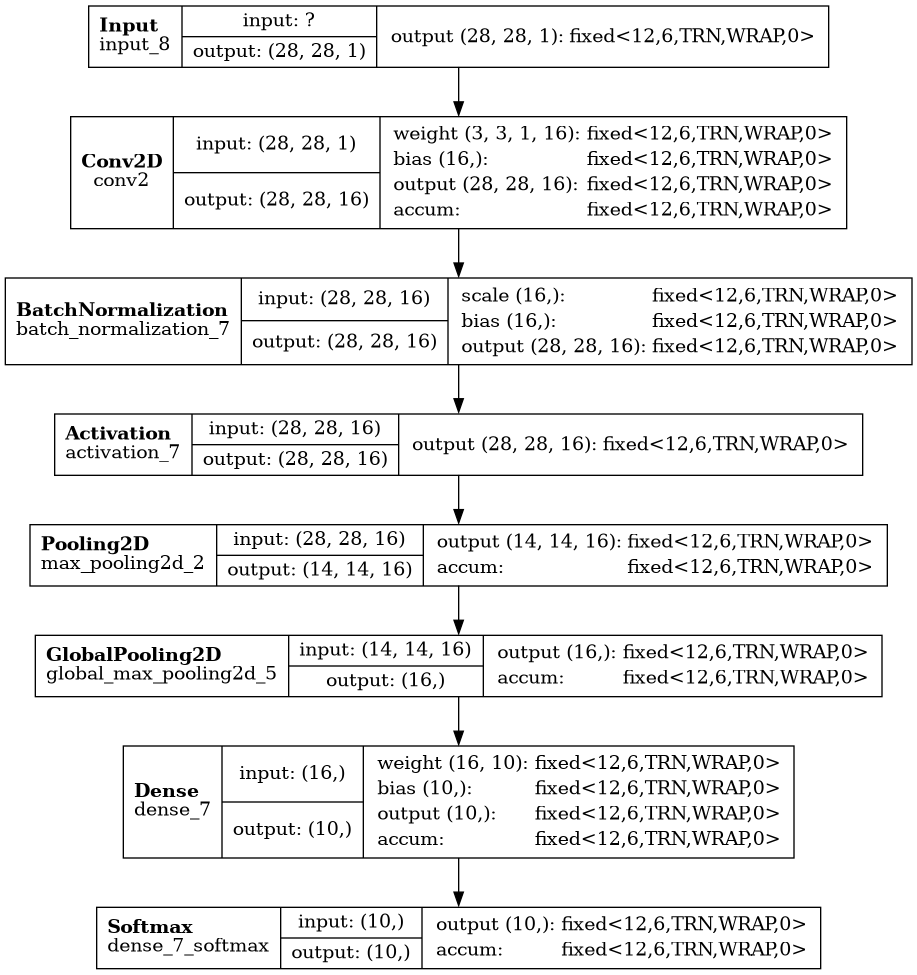

In [ ]:
import hls4ml
config = hls4ml.utils.config_from_keras_model(model, granularity='model')

config['Model']['ReuseFactor'] = 9
config['Model']['Strategy'] = 'Resource'
config['Model']['Precision'] = 'ap_fixed<10,6>'

hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Compiling and Predicting

In [101]:
hls_model.compile()
x_test = np.ascontiguousarray(x_test)
y_hls = hls_model.predict(x_test)

## Compare the hls4ml model accuracy with Keras model accuracy

In [102]:
# Print Accuracy Comparison
keras_acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))
hls_acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))

print(f"Keras  Accuracy: {keras_acc:.4f}")
print(f"hls4ml Accuracy: {hls_acc:.4f}")

# Numerical ROC/AUC Comparison
print("\nNumerical AUC Comparison (Keras vs hls4ml):")
print("-" * 45)
print(f"{'Digit':<10} | {'Keras AUC':<12} | {'hls4ml AUC':<12}")
print("-" * 45)

n_classes = 10
for i in range(n_classes):
    # Keras AUC
    fpr_k, tpr_k, _ = roc_curve(y_test[:, i], y_keras[:, i])
    auc_k = auc(fpr_k, tpr_k)
    
    # hls4ml AUC
    fpr_h, tpr_h, _ = roc_curve(y_test[:, i], y_hls[:, i])
    auc_h = auc(fpr_h, tpr_h)
    
    print(f"{i:<10} | {auc_k:<12.4f} | {auc_h:<12.4f}")

Keras  Accuracy: 0.6317
hls4ml Accuracy: 0.1020

Numerical AUC Comparison (Keras vs hls4ml):
---------------------------------------------
Digit      | Keras AUC    | hls4ml AUC  
---------------------------------------------
0          | 0.9199       | 0.5115      
1          | 0.9964       | 0.4925      
2          | 0.8341       | 0.5013      
3          | 0.9608       | 0.4998      
4          | 0.9653       | 0.5013      
5          | 0.9385       | 0.5038      
6          | 0.9149       | 0.5080      
7          | 0.9645       | 0.4926      
8          | 0.9396       | 0.4960      
9          | 0.9290       | 0.4952      


In [99]:
# ---------------------------------------------------------
# INTERCEPT AND FIX THE TCL SCRIPT FOR VITIS HLS 2024.1
# ---------------------------------------------------------
tcl_script_path = 'model_1/hls4ml_prj/build_prj.tcl'

if os.path.exists(tcl_script_path):
    with open(tcl_script_path, 'r') as file:
        tcl_content = file.read()
    
    # Replace the deprecated flag with the correct 2024.1 flag
    tcl_content = tcl_content.replace('-maximum_size', '-complete_threshold')
    
    with open(tcl_script_path, 'w') as file:
        file.write(tcl_content)
    print("Patched build_prj.tcl for Vitis HLS 2024.1 compatibility.")

Patched build_prj.tcl for Vitis HLS 2024.1 compatibility.


## Synthesizing the hls4ml model

In [71]:
# hls_model.build(csim=False, synth=True, cosim=True, export=True) # Vitis (synthesis) only
hls_model.build(csim=False, synth=True, cosim=True, export=True, vsynth=True) # Vitis (synthesis) and Vivado (PnR)


****** vitis-run v2024.1 (64-bit)
  **** SW Build 5074859 on 2024-05-20-23:21:20
  **** Start of session at: Wed Mar 11 09:38:52 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/j.lim.473/ece226/ECE226_CoDesign/model_1/hls4ml_prj/build_prj.tcl -work_dir /home/j.lim.473/ece226/ECE226_CoDesign/model_1/hls4ml_prj

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Wed Mar 11 09:38:53 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2024.1/scripts/vitis_hls/hls.tcl -notrace
INFO: [

KeyboardInterrupt: 

## Printing out reports

In [ ]:
hls4ml.report.read_vivado_report('model_1/hls4ml_prj/')

In [ ]:
!cp model_1/hls4ml_prj/vivado_synth.rpt .